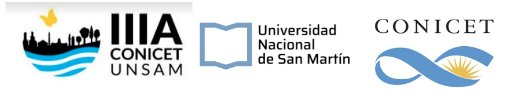  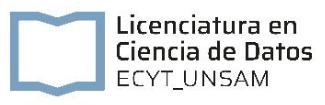

---

# NB04 — Integración raster-vectorial y dataset etiquetado

Lo que veremos en esta notebook:

- [x] Recorte preciso de raster con polígonos y el flujo de datos raster↔vector
- [x] Extracción de valores raster por ROI: arrays enmascarados
- [x] Estadísticas zonales: promedio, mediana y varianza por polígono
- [x] Diseño de regiones de interés (ROIs) y decisiones de muestreo
- [x] Construcción de un dataset etiquetado $(X, y)$ para aprendizaje supervisado
- [x] El problema del desbalance de clases y cómo pensarlo
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Cruzar datos raster y vectoriales con Rasterio y GeoPandas de forma georeferenciada y confiable.
- Calcular estadísticas zonales defensivas (que manejan NoData y polígonos sin datos) y agregarlas como atributos vectoriales.
- Diseñar ROIs de entrenamiento para un mapa de coberturas, discutiendo tamaño, pureza y representatividad.
- Construir un dataset etiquetado $(X, y)$ a nivel de píxel desde imágenes multitemporales.
- Reconocer y cuantificar desbalance de clases antes de entrenar un clasificador.

### Datos con los que trabajaremos

- Productos raster de NB02:
  - `data/proc/indices_dique_2026feb.tif` — NDVI, NDWI, NIR para la zona del Dique Roggero.
  - `data/raw_data/satelital/S2_AMBANO_B02B03B04B08_2026feb.tif` — imagen S2 del corredor noroeste AMBA, feb 2026.
  - `data/raw_data/satelital/S2_AMBANO_B02B03B04B08_2015ago.tif` — imagen S2 del corredor noroeste AMBA, ago 2015 (usada en Ejercicio 2).
- Producto vectorial de NB03:
  - `data/proc/radios_vulnerabilidad.gpkg` — radios censales con variables de vulnerabilidad (13 partidos).
- Archivo nuevo:
  - `data/raw_data/vectorial/rois_dique.geojson` — polígonos de entrenamiento digitalizados en QGIS por el docente, con 6 clases de cobertura.

### Conexión con el arco del curso

Esta notebook es una **bisagra técnica**: es donde por primera vez los dos modelos de datos del curso —raster y vectorial— se encuentran en un pipeline. Los productos de esta clase van a alimentar casi todo lo que viene:

- El **dataset etiquetado** $(X, y)$ → NB05 (EDA), NB06 (validación post-hoc del clustering), NB08 (clasificación supervisada).
- Las **estadísticas zonales** espectrales por radio → NB10 (autocorrelación espacial), NB12 (variables del modelo de regresión).

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd

from ade_tools import componer_rgb, ecualizar_rgb, guardar_geotiff

RAW  = 'data/raw_data/'
PROC = 'data/proc/'
OUT  = 'data/out/'

FN_IMG     = RAW  + 'satelital/S2_AMBANO_B02B03B04B08_2026feb.tif'
FN_RADIOS  = PROC + 'radios_vulnerabilidad.gpkg'
FN_ROIS    = RAW  + 'vectorial/rois_dique.geojson'
FN_ZONA    = RAW  + 'vectorial/zona_dique.geojson'

# Orden canónico de las clases de cobertura, usado de acá en adelante en TODAS
# las notebooks del curso. Respeta una secuencia semántica (de agua a urbano,
# de natural a antrópico) que facilita leer matrices y firmas espectrales.
# Las demás notebooks lo re-declaran al principio para evitar dependencias.
CLASES_ORD = ('agua', 'humedal', 'veg_densa', 'suelo_desnudo', 'urbano_denso', 'periurbano')

---
# 1. Estadísticas zonales: raster resumido por polígonos

Una operación recurrente al mezclar raster con vector es calcular un **estadístico de los píxeles que caen dentro de cada polígono**. Por ejemplo: la mediana del NDVI en cada radio censal es una variable útil para correlacionar cobertura vegetal con variables socioeconómicas.

Esto se llama **zonal statistics**. El procedimiento conceptual es:

1. Para cada polígono, recortar el raster por su geometría.
2. Extraer los valores válidos (no-NoData) del recorte.
3. Calcular el estadístico.

Rasterio provee `rasterio.mask.mask` para el recorte. El resto es NumPy.

In [ ]:
def estadisticas_zonales(fn_raster, gdf, stats=('mean','median','std'), banda=1):
    """
    Para cada geometría de gdf, extrae los píxeles de la banda indicada de fn_raster
    y devuelve un DataFrame con los estadísticos pedidos.

    Parámetros
    ----------
    fn_raster : str — path al GeoTIFF
    gdf       : GeoDataFrame — debe estar en el mismo CRS que el raster
    stats     : tupla de strings entre {'mean','median','std','min','max','n_validos'}
    banda     : int (1-indexed)

    Notas
    -----
    - Si un polígono no tiene píxeles válidos (todos NoData o fuera del raster),
      devuelve NaN en los estadísticos y 0 en 'n_validos'. No lanza excepción.
    - La geometría del gdf y el raster deben compartir el mismo CRS. Verificamos adentro.
    """
    import rasterio
    from rasterio.mask import mask as rasterio_mask
    import numpy as np

    funcs = {'mean':np.nanmean, 'median':np.nanmedian, 'std':np.nanstd,
             'min':np.nanmin, 'max':np.nanmax,
             'n_validos': lambda a: int(np.sum(~np.isnan(a)))}

    resultados = {s: [] for s in stats}

    with rasterio.open(fn_raster) as src:
        if src.crs != gdf.crs:
            raise ValueError(f'CRS no coinciden: raster={src.crs}, gdf={gdf.crs}')
        nodata = src.nodata
        for geom in gdf.geometry:
            try:
                recorte, _ = rasterio_mask(src, [geom.__geo_interface__],
                                            crop=True, filled=True)
                arr = recorte[banda-1].astype(float)
                if nodata is not None:
                    arr[arr == nodata] = np.nan
                validos = arr[~np.isnan(arr)]
                if validos.size == 0:
                    for s in stats: resultados[s].append(np.nan if s != 'n_validos' else 0)
                    continue
                for s in stats: resultados[s].append(funcs[s](validos))
            except (ValueError, Exception):
                for s in stats: resultados[s].append(np.nan if s != 'n_validos' else 0)

    import pandas as pd
    return pd.DataFrame(resultados, index=gdf.index)

> **`estadisticas_zonales()` → `ade_tools.py`**

Tres decisiones de diseño que vale la pena notar:

1. **Fail-soft en polígonos sin datos**: si un radio queda fuera del raster o todos sus píxeles son NoData, la función devuelve NaN en vez de romper. Eso permite correr el análisis sobre miles de polígonos sin tener que ponerle try/except afuera.
2. **Verificación de CRS**: si el raster y el vector no están en el mismo CRS, el recorte pega geometrías donde no corresponde y las estadísticas salen mal **sin avisar**. Por eso chequeamos explícitamente.
3. **`n_validos`**: incluirlo como estadístico es útil para saber cuán confiables son los números — un promedio sobre 2 píxeles pesa distinto que uno sobre 20000.

---
# 2. Estadísticas espectrales por radio censal

In [ ]:
# Cargamos los radios y armamos el stack de variables por radio
gdf_radios = gpd.read_file(FN_RADIOS)

# NDVI por radio: primero calculamos NDVI sobre toda la imagen y lo guardamos
with rasterio.open(FN_IMG) as src:
    imagen = src.read().astype(float)
    perfil = src.profile.copy()

ESCALA = 10_000.0
rojo = imagen[2] / ESCALA
nir  = imagen[3] / ESCALA
ndvi_full = np.where((nir + rojo) != 0, (nir - rojo) / (nir + rojo), np.nan)

guardar_geotiff(PROC + 'ndvi_completo_2026feb.tif',
                ndvi_full.astype(np.float32), perfil,
                nodata=np.nan, nombres_bandas=['NDVI'])

In [ ]:
# Ahora extraemos estadísticas zonales de NDVI por radio
stats_ndvi = estadisticas_zonales(
    PROC + 'ndvi_completo_2026feb.tif',
    gdf_radios,
    stats=('mean','median','std','n_validos'),
    banda=1
)

# Las agregamos al GeoDataFrame con nombre distinguible
stats_ndvi.columns = ['ndvi_media','ndvi_mediana','ndvi_std','n_px_validos']
gdf_radios = gdf_radios.join(stats_ndvi)

print(gdf_radios[['cod_radio','ndvi_media','ndvi_mediana','ndvi_std','n_px_validos']].head())
print()
print(f'Radios sin datos (caen fuera del raster): {gdf_radios.ndvi_media.isna().sum()}')

In [ ]:
# Visualizamos el NDVI mediano por radio
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

gdf_radios.plot(column='ndvi_mediana', cmap='RdYlGn', legend=True,
                scheme='quantiles', k=5,
                edgecolor='gray', linewidth=0.1,
                legend_kwds={'title':'NDVI mediano', 'fmt':'{:.2f}', 'loc': 'lower right'}, ax=axes[0])
axes[0].set_title('NDVI mediano por radio censal\n(feb 2026)')
axes[0].set_axis_off()

gdf_radios.plot(column='nbi_pct', cmap='YlOrRd', legend=True,
                scheme='quantiles', k=5,
                edgecolor='gray', linewidth=0.1,
                legend_kwds={'title':'NBI %', 'fmt':'{:.1f}', 'loc': 'lower right'}, ax=axes[1])
axes[1].set_title('NBI por radio censal\n(Censo 2022)')
axes[1].set_axis_off()

plt.suptitle('Dos vistas del mismo territorio — ¿existe asociación entre vegetación y vulnerabilidad?', fontsize=13)
plt.tight_layout()
plt.show()

La comparación visual sugiere una asociación negativa entre cobertura vegetal y NBI — los radios con más vegetación tienden a ser los de menor vulnerabilidad. Pero no alcanza con mirar los mapas: la sensación visual es fácil de engañar, y el territorio tiene estructura espacial que puede producir correlaciones espurias.

En **NB10** vamos a cuantificar esta asociación rigurosamente: con el índice de Moran bivariado y los clústeres LISA entre estas dos variables. Y en **NB13** vamos a modelarla con regresión espacial que controla por autocorrelación.

Guardamos el GeoDataFrame enriquecido:

In [ ]:
gdf_radios.to_file(PROC + 'radios_con_stats_espectrales.gpkg', driver='GPKG')
print(f'Guardado: {PROC}radios_con_stats_espectrales.gpkg')

---
# 3. Regiones de interés y muestreo de píxeles

Para entrenar un clasificador supervisado de cobertura del suelo (en **NB08**) necesitamos un **dataset etiquetado**: un conjunto de píxeles de los cuales conocemos la clase correcta. Estas etiquetas se construyen a partir de **ROIs** (*Regions of Interest*): polígonos vectoriales que digitalizamos sobre zonas claramente interpretables de la imagen, asignando una etiqueta de clase a cada polígono.

El conjunto de clases que vamos a usar en el curso:

| Clase | Etiqueta | Descripción |
|---|---|---|
| `agua`         | 1 | Espejo de agua del Dique, río Reconquista |
| `humedal`      | 2 | Bañados, pastizales húmedos bajos |
| `bosque`       | 3 | Bosque, parques arbolados, plantaciones densas |
| `rural`| 4 | Suelo sin cobertura, barbecho, áreas erosionadas, cultivos, pastizales |
| `urbano` | 5 | Manzanas urbanas consolidadas (techos + calles) |

> **¿Por qué nos dan los ROIs ya hechos?** Digitalizar ROIs de calidad requiere oficio: hay que balancear cantidad por clase, evitar píxeles mixtos en los bordes, tener variedad geográfica dentro de cada clase. Hacerlo mal es una fuente común de errores que después se leen como fallas del algoritmo de clasificación. En este TP te damos los ROIs para que el trabajo sea sobre los algoritmos y no sobre la digitalización. El Ejercicio 3 pide modificar los ROIs, una experiencia más controlada.

In [ ]:
# Cargamos ROIs
gdf_rois = gpd.read_file(FN_ROIS)

# Chequeos básicos
print(f'CRS ROIs: {gdf_rois.crs}')
print()
print('ROIs por clase:')
print(gdf_rois.groupby('clase').agg(n_poligonos=('geometry','count'),
                                     area_ha=('geometry', lambda g: (g.area / 10_000).sum())).round(2))
print()
print(f'Total: {len(gdf_rois)} polígonos')

In [ ]:
# Visualización: los ROIs sobre la composición color natural
with rasterio.open(FN_IMG) as src:
    crs_img = src.crs

gdf_rois_utm = gdf_rois.to_crs(crs_img)
gdf_zona = gpd.read_file(FN_ZONA).to_crs(crs_img)

with rasterio.open(FN_IMG) as src:
    geoms_zona = [gdf_zona.geometry.iloc[0].__geo_interface__]
    imagen_zona, T_zona = rasterio_mask(src, geoms_zona, crop=True)

from rasterio.plot import plotting_extent
extent = plotting_extent(imagen_zona[0], T_zona)

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(componer_rgb(imagen_zona, [2, 1, 0]), extent=extent)

colores = {'agua':'blue','humedal':'cyan','bosque':'green',
           'rural':'peru','urbano':'red'}
for clase, color in colores.items():
    sub = gdf_rois_utm[gdf_rois_utm['clase'] == clase]
    sub.plot(ax=ax, edgecolor=color, facecolor='none', linewidth=2, label=clase)

ax.legend(loc='lower right', framealpha=0.9)
ax.set_title('ROIs de entrenamiento sobre composición color natural — Dique Roggero')
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
# 4. Construcción del dataset etiquetado (X, y)

Ahora convertimos los ROIs en un dataset de **píxeles etiquetados**:

- Para cada ROI, extraemos todos los píxeles de la imagen Sentinel-2 que caen dentro.
- Cada píxel es una fila de $X$ con sus 4 valores de banda.
- El vector $y$ guarda la clase correspondiente.

El resultado es $X$ de forma $(n_{\text{pixels}}, 4)$ y $y$ de forma $(n_{\text{pixels}},)$.

Además vamos a agregar los dos índices calculados sobre las mismas posiciones, ampliando $X$ a 6 features: `[B02, B03, B04, B08, NDVI, NDWI]`.

In [ ]:
def extraer_pixeles_por_roi(fn_raster, gdf_rois, columna_clase='clase'):
    """
    Extrae píxeles de todas las bandas de fn_raster dentro de cada ROI de gdf_rois.
    Devuelve:
      X     : array (n_pixels, n_bandas)
      y     : array (n_pixels,) con la clase como string
      ids   : array (n_pixels,) con el id del polígono ROI origen (para K-fold espacial en NB08)

    Implementación: usa rasterio.mask.mask con filled=False, que devuelve un
    MaskedArray con la máscara correcta. Esto evita el caso borde donde un
    píxel real tiene valor 0 en alguna banda y sería descartado erróneamente
    si asumiéramos nodata=0.
    """
    import rasterio
    from rasterio.mask import mask as rasterio_mask
    import numpy as np

    X_list, y_list, id_list = [], [], []
    with rasterio.open(fn_raster) as src:
        if src.crs != gdf_rois.crs:
            raise ValueError(f'CRS no coinciden: raster={src.crs}, gdf_rois={gdf_rois.crs}')
        for idx, row in gdf_rois.iterrows():
            # filled=False devuelve (MaskedArray, transform).
            # np.ma.getmaskarray garantiza un array booleano aunque el MaskedArray
            # tenga mask=False escalar (ocurre cuando el raster no declara nodata).
            recorte, _ = rasterio_mask(src, [row.geometry.__geo_interface__],
                                        crop=True, filled=False)
            mask_arr = np.ma.getmaskarray(recorte)
            # Válido = no enmascarado en NINGUNA banda
            validos = ~np.any(mask_arr, axis=0)
            px = np.asarray(recorte.data)[:, validos].T   # (n_px, n_bandas)
            if px.shape[0] == 0:
                continue
            X_list.append(px)
            y_list.append(np.full(px.shape[0], row[columna_clase]))
            id_list.append(np.full(px.shape[0], idx))

    return np.vstack(X_list), np.concatenate(y_list), np.concatenate(id_list)

In [ ]:
# Extraemos las bandas B02 B03 B04 B08 de la imagen S2
X_bandas, y, ids_roi = extraer_pixeles_por_roi(FN_IMG, gdf_rois_utm)
print(f'X_bandas shape: {X_bandas.shape}')
print(f'y shape       : {y.shape}')
print(f'ids_roi shape : {ids_roi.shape}')
print()
print('Píxeles por clase:')
vals, counts = np.unique(y, return_counts=True)
for v, c in zip(vals, counts): print(f'  {v:15s} : {c:6d}')

In [ ]:
# Calculamos NDVI y NDWI píxel a píxel
ESCALA = 10_000.0
azul  = X_bandas[:, 0] / ESCALA
verde = X_bandas[:, 1] / ESCALA
rojo  = X_bandas[:, 2] / ESCALA
nir   = X_bandas[:, 3] / ESCALA

ndvi_px = np.where((nir + rojo) != 0, (nir - rojo) / (nir + rojo), np.nan)
ndwi_px = np.where((verde + nir) != 0, (verde - nir) / (verde + nir), np.nan)

# Stack final: 6 features
X = np.column_stack([X_bandas / ESCALA, ndvi_px, ndwi_px])
print(f'X final: {X.shape}  — columnas: [B02, B03, B04, B08, NDVI, NDWI]')
print()
print('Estadísticos por columna:')
nombres_col = ['B02','B03','B04','B08','NDVI','NDWI']
for i, n in enumerate(nombres_col):
    print(f'  {n:5s}: [{X[:,i].min():+.3f}, {X[:,i].max():+.3f}]  media: {X[:,i].mean():+.3f}')

---
# 5. Decisiones de muestreo que no son triviales

La construcción de un dataset etiquetado tiene decisiones que impactan fuerte en la calidad del modelo final. Hacerlas explícitas ayuda a diagnosticar cuando algo sale mal:

### 5.1 Tamaño por clase y desbalance

Nuestras clases no están balanceadas: el agua tiene decenas de miles de píxeles, el humedal apenas un par de miles. Esto tiene dos orígenes distintos: hay más área real de una clase que de otra (por ejemplo, más urbano que humedal) y hay ROIs de tamaños muy distintos.

Como **regla práctica** de cuántos píxeles necesitamos por clase, Jensen (1996, *Introductory Digital Image Processing*) sugiere un mínimo de $10 \cdot p$ píxeles por clase donde $p$ es la cantidad de features, idealmente $100 \cdot p$ para tener robustez. Con nuestras 6 features, esto son 60 mínimo y 600 ideal. Nuestros ROIs superan ese umbral para todas las clases — lo verificamos abajo.

Dos estrategias para manejar desbalance en el entrenamiento:

- **Pesos de clase** (`class_weight='balanced'` en sklearn): penaliza más los errores de clases minoritarias.
- **Submuestreo / Sobremuestreo**: igualar el número de ejemplos por clase antes de entrenar.

Ninguna es "correcta" en abstracto. Lo vamos a retomar en NB08.

### 5.2 Pureza espectral y píxeles de borde

Los píxeles en los bordes de un ROI pueden estar mezclados entre dos coberturas. Para el entrenamiento conviene apuntar al **corazón** de cada zona pura. Nuestros ROIs ya fueron digitalizados con esa lógica, pero vale la pena chequear que los valores extremos (que suelen ser píxeles mixtos) no estén reventando las distribuciones por clase.

### 5.3 Representatividad geográfica

Las 6 clases tienen múltiples ROIs distribuidos en el territorio: no queremos que "urbano denso" se aprenda solo a partir del centro de Moreno sin haber visto Merlo u otro partido del conurbano. La diversidad geográfica intra-clase mejora la generalización y es crítica para hacer **K-fold espacial** en NB08 (donde el ID del ROI origen, que guardamos en `ids_roi`, va a servir como grupo para la validación cruzada).

In [ ]:
# Visualizamos el desbalance
counts = pd.Series(y).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
counts.plot(kind='barh', color='steelblue', ax=ax)
for i, v in enumerate(counts.values):
    ax.text(v + counts.max()*0.01, i, f'{v}', va='center')
ax.set_xlabel('Cantidad de píxeles')
ax.set_title(f'Distribución de píxeles por clase en el dataset etiquetado\n'
             f'Total: {len(y)} — ratio min/max: {counts.min()/counts.max():.3f}')
plt.tight_layout()
plt.show()

---
# 6. Guardado del dataset etiquetado

In [ ]:
np.savez(PROC + 'dataset_etiquetado.npz',
         X=X, y=y, ids_roi=ids_roi,
         nombres_features=np.array(['B02','B03','B04','B08','NDVI','NDWI']))

print(f'Guardado: {PROC}dataset_etiquetado.npz')
print(f'  X shape: {X.shape}')
print(f'  y shape: {y.shape}')
print(f'  ids_roi shape: {ids_roi.shape}')

# Verificación: volvemos a cargarlo
data = np.load(PROC + 'dataset_etiquetado.npz', allow_pickle=True)
print(f'\nVerificación: claves en el archivo = {list(data.keys())}')

Este archivo es el insumo central de las próximas tres clases:

- **NB05** lo usa para EDA: firmas espectrales, separabilidad de clases, PCA.
- **NB06** lo usa como **validación post-hoc**: vamos a correr clustering *no supervisado* sobre la imagen y comparar los clústeres con nuestras etiquetas para ver qué descubre el algoritmo sin mirar la información humana.
- **NB08** lo usa para entrenar clasificadores supervisados (KNN, Random Forest) y `ids_roi` nos va a servir para diseñar la validación cruzada **espacial**.

---
# Ejercicios de entrega

---

## Ejercicio 1 — Estadísticas zonales

a) Modificá `estadisticas_zonales` para que acepte una lista de bandas y calcule estadísticas de todas en una sola pasada. Aplicala sobre el GeoTIFF `indices_dique_2026feb.tif` (que tiene NDVI, NDWI, NIR) y los polígonos de vulnerabilidad.

b) Construí un scatter plot entre `ndvi_mediana` y `nbi_pct`, coloreando los puntos por partido. ¿Se ve una tendencia? ¿Qué signo esperás y por qué?

c) Calculá la correlación de Pearson y la de Spearman entre ambas variables. ¿Difieren? ¿Cómo podés interpretar la diferencia?

---

## Ejercicio 2 — Extracción de píxeles sobre otra imagen

a) Aplicá `extraer_pixeles_por_roi` sobre las imagenes de **agosto 2015 y 2025**. Nombrá el resultado `X_2015, y_2015, ids_2015` y análogamente para 2025. Verificá que las `y` nuevas tengan las mismas etiquetas que `y` (son los mismos ROIs, otra imagen).

b) Hacé un histograma lado a lado de NDVI por clase para 2025 y 2026. ¿Se ve desplazamiento? Recordá que 2025 es invierno y 2026 es verano — el desplazamiento esperado es estacional, no de cambio real. Repetí para 2015 y 2025.

c) Guardá los dataset en `data/proc/dataset_etiquetado_2015ago.npz` y `data/proc/dataset_etiquetado_2025ago.npz`. Lo vamos a usar más adelante para entrenar un clasificador sobre 2015 que en NB11 nos dará el mapa de cobertura histórico para detección de cambios.

---

## Ejercicio 3 — Impacto de los ROIs en la clasificación

Modificá los ROIs de alguna manera deliberada y chequeá el efecto:

a) **Reducción**: eliminá todos salvo dos polígonos de la clase `bosque`. Rearmá el dataset.

b) **Contaminación**: a uno de los ROIs de `urbano`, cambiale manualmente la etiqueta poniéndole `bosque`. Esto simula un error de etiquetado.

c) Calculá para cada dataset (original, reducido, contaminado) la media y la desviación estándar de NDVI en la clase `bosque`. Reportá las tres filas. ¿Qué decisión tomarías ante estos resultados?

*(Los resultados van a hacer más evidente por qué en NB08 usamos K-fold espacial y no K-fold estándar: un K-fold ingenuo sobre datos contaminados subestima el error del modelo.)*

---

## Ejercicio opcional — Literatura sobre muestreo

Lee **Stehman (2009)** "*Sampling designs for accuracy assessment of land cover*" (Int. J. Remote Sensing). Resumí brevemente el argumento central de por qué el muestreo **estratificado** es preferido al aleatorio simple para evaluación de mapas de cobertura.

*Referencia adicional:* "*Key issues in rigorous accuracy assessment of land cover products*" de Stehman y Foody (2019, Remote Sensing of Environment) tiene información clave para entender el diseño de muestreo para una  evalaución de calidad de mapas de cobertura. Leélo si estás interesadx en el tema.

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

En esta clase incorporamos a `ade_tools.py`:

- `estadisticas_zonales(fn_raster, gdf, stats, banda)`
- `extraer_pixeles_por_roi(fn_raster, gdf_rois, columna_clase)`

```python
# ade_tools.py (funciones nuevas)

def estadisticas_zonales(fn_raster, gdf, stats=('mean','median','std'), banda=1):
    """Estadísticos de píxeles por polígono, fail-soft en polígonos sin datos."""
    # [implementación completa, ver celda 1.X]

def extraer_pixeles_por_roi(fn_raster, gdf_rois, columna_clase='clase'):
    """Dataset etiquetado (X, y, ids) a partir de ROIs vectoriales."""
    # [implementación completa, ver celda 4.X]
```